## 기존 기상정보 + 분당 강수량 병합

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [23]:
df=pd.read_csv('./기상정보_0708.csv',encoding='cp949')
df.head()

,사업소,호기,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,-,2023-01-01,-3.96,46.07,325.03,1.51,NaN,NaN,-3.96,46.07,325.03,1.51,NaN,NaN
1,분당,-,2023-01-02,-7.45,63.39,324.52,1.44,NaN,NaN,-7.45,63.39,324.52,1.44,NaN,NaN
2,분당,-,2023-01-03,-7.28,56.97,325.07,1.49,NaN,NaN,-7.28,56.97,325.07,1.49,NaN,NaN
3,분당,-,2023-01-04,-5.12,68.63,324.83,1.50,NaN,NaN,-5.12,68.63,324.83,1.50,NaN,NaN
4,분당,-,2023-01-05,-4.20,72.47,324.25,1.42,NaN,NaN,-4.20,72.47,324.25,1.42,NaN,NaN


In [75]:
df['호기'].unique()

array(['-', nan], dtype=object)

In [4]:
df.tail()

,사업소,호기,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
3336,영흥,NaN,2024-12-27,-1.658,53.832,228.650,0.904,0.0,NaN,-1.658,53.832,228.650,0.904,0.0,NaN
3337,영흥,NaN,2024-12-28,-0.254,54.276,175.784,0.082,0.0,NaN,-0.254,54.276,175.784,0.082,0.0,NaN
3338,영흥,NaN,2024-12-29,3.162,63.050,78.314,0.710,0.0,NaN,3.162,63.050,78.314,0.710,0.0,NaN
3339,영흥,NaN,2024-12-30,5.156,56.640,208.536,2.320,0.0,NaN,5.156,56.640,208.536,2.320,0.0,NaN
3340,영흥,NaN,2024-12-31,-0.368,55.346,202.634,0.222,0.0,NaN,-0.368,55.346,202.634,0.222,0.0,NaN


In [5]:
df.shape

(3341, 15)

In [78]:
df.isna().sum()

사업소          0
호기         610
일자           0
기온           1
습도           1
풍향           1
풍속           4
강수량        743
기압        1942
대기안정도      732
증발량        732
일조시간       732
전일강수량      732
60분강수량    1472
금일강수량     1944
dtype: int64

In [79]:
df.shape

(3341, 15)

In [80]:
df.describe()

,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
count,3340.000000,3340.000000,3340.000000,3337.000000,2598.000000,1399.000000,2609.000000,2609.000000,2609.000000,2609.000000,1869.000000,1397.000000
mean,12.980378,72.872411,209.976764,2.593972,3.293245,1010.058017,12.067559,74.035650,214.740856,2.329622,2.283494,487.618346
std,9.591118,18.928681,101.453193,1.883172,15.354607,8.033832,9.607689,19.393327,102.960915,1.810390,11.305376,503.719487
min,-16.220000,17.910000,0.000000,0.010000,0.000000,984.183333,-16.220000,17.910000,0.000000,0.010000,0.000000,0.000000
25%,5.284500,58.484000,126.250500,1.390000,0.000000,1003.960417,4.226000,59.383333,126.890000,1.172000,0.000000,0.000000
50%,13.580000,75.115000,229.430000,2.300000,0.000000,1010.230000,12.870000,76.920000,231.250000,2.240000,0.000000,46.500000
75%,21.200000,89.132500,298.397000,3.100000,0.000000,1015.895000,20.406000,90.990000,330.020000,2.650000,0.000000,1013.300000
max,32.100000,100.000000,358.900000,19.650000,328.000000,1031.710000,31.810000,100.000000,347.330000,19.650000,316.000000,1031.710000


In [81]:
df.describe(include='O')

,사업소,호기,일자
count,3341,2731,3341
unique,5,1,731
top,여수,-,2023-01-01
freq,731,2731,5


In [82]:
df.groupby(['사업소','호기']).count()

,,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
사업소,호기,,,,,,,,,,,,,
분당,-,728,728,728,728,728,0,0,728,728,728,728,0,0
삼천포,-,603,603,603,603,603,603,0,603,603,603,603,603,0
여수,-,731,731,731,731,728,729,731,0,0,0,0,0,729
영동,-,669,668,668,668,668,668,668,668,668,668,668,668,668


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3341 entries, 0 to 3340
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   사업소     3341 non-null   object 
 1   호기      2731 non-null   object 
 2   일자      3341 non-null   object 
 3   기온      3340 non-null   float64
 4   습도      3340 non-null   float64
 5   풍향      3340 non-null   float64
 6   풍속      3337 non-null   float64
 7   강수량     2598 non-null   float64
 8   기압      1399 non-null   float64
 9   대기안정도   2609 non-null   float64
 10  증발량     2609 non-null   float64
 11  일조시간    2609 non-null   float64
 12  전일강수량   2609 non-null   float64
 13  60분강수량  1869 non-null   float64
 14  금일강수량   1397 non-null   float64
dtypes: float64(12), object(3)
memory usage: 391.6+ KB


In [25]:
df['일자']=pd.to_datetime(df['일자'],format='%Y-%m-%d')
df.head(2)

,사업소,호기,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,-,2023-01-01,-3.96,46.07,325.03,1.51,NaN,NaN,-3.96,46.07,325.03,1.51,NaN,NaN
1,분당,-,2023-01-02,-7.45,63.39,324.52,1.44,NaN,NaN,-7.45,63.39,324.52,1.44,NaN,NaN


In [26]:
df.drop('호기',axis=1, inplace=True)

In [9]:
df.head(2)

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,NaN,NaN,-3.96,46.07,325.03,1.51,NaN,NaN
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,NaN,NaN,-7.45,63.39,324.52,1.44,NaN,NaN


In [10]:
df.shape

(3341, 14)

In [88]:
df[df['사업소']=='삼천포'][['기온','습도','강수량']].describe()

,기온,습도,강수량
count,603.000000,603.000000,603.000000
mean,15.500050,79.685738,2.652338
std,8.532865,16.144518,9.442367
min,-9.180000,29.890000,0.000000
25%,9.610000,69.450000,0.000000
50%,16.470000,84.650000,0.000000
75%,23.090000,92.125000,0.250000
max,28.590000,100.000000,95.820000


In [27]:
df.isna().sum()

사업소          0
일자           0
기온           1
습도           1
풍향           1
풍속           4
강수량        743
기압        1942
대기안정도      732
증발량        732
일조시간       732
전일강수량      732
60분강수량    1472
금일강수량     1944
dtype: int64

In [90]:
df.head()

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,NaN,NaN,-3.96,46.07,325.03,1.51,NaN,NaN
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,NaN,NaN,-7.45,63.39,324.52,1.44,NaN,NaN
2,분당,2023-01-03,-7.28,56.97,325.07,1.49,NaN,NaN,-7.28,56.97,325.07,1.49,NaN,NaN
3,분당,2023-01-04,-5.12,68.63,324.83,1.50,NaN,NaN,-5.12,68.63,324.83,1.50,NaN,NaN
4,분당,2023-01-05,-4.20,72.47,324.25,1.42,NaN,NaN,-4.20,72.47,324.25,1.42,NaN,NaN


In [91]:
df.columns

Index(['사업소', '일자', '기온', '습도', '풍향', '풍속', '강수량', '기압', '대기안정도', '증발량',
       '일조시간', '전일강수량', '60분강수량', '금일강수량'],
      dtype='object')

In [28]:
df.drop(['기압', '대기안정도', '증발량',
       '일조시간', '전일강수량', '60분강수량', '금일강수량'],axis=1,inplace=True)

In [29]:
df.head()

,사업소,일자,기온,습도,풍향,풍속,강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,NaN
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,NaN
2,분당,2023-01-03,-7.28,56.97,325.07,1.49,NaN
3,분당,2023-01-04,-5.12,68.63,324.83,1.50,NaN
4,분당,2023-01-05,-4.20,72.47,324.25,1.42,NaN


In [13]:
df['사업소'].value_counts()

여수     731
분당     728
영동     669
영흥     610
삼천포    603
Name: 사업소, dtype: int64

In [95]:
df.head()

,사업소,일자,기온,습도,풍향,풍속,강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,NaN
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,NaN
2,분당,2023-01-03,-7.28,56.97,325.07,1.49,NaN
3,분당,2023-01-04,-5.12,68.63,324.83,1.50,NaN
4,분당,2023-01-05,-4.20,72.47,324.25,1.42,NaN


In [96]:
df[df['사업소']=='영흥']['일자'].value_counts()[100:160]

일자
2024-01-05    1
2024-01-06    1
2024-01-07    1
2024-01-08    1
2024-01-09    1
2024-01-10    1
2024-01-11    1
2024-01-12    1
2024-01-13    1
2024-01-14    1
2024-01-15    1
2024-01-16    1
2024-01-17    1
2024-02-06    1
2024-02-08    1
2024-03-15    1
2024-02-27    1
2024-02-29    1
2024-03-01    1
2024-03-02    1
2024-03-03    1
2024-03-04    1
2024-03-05    1
2024-03-06    1
2024-03-07    1
2024-03-08    1
2024-03-09    1
2024-03-10    1
2024-03-11    1
2024-03-12    1
2024-03-13    1
2024-03-14    1
2024-02-28    1
2024-02-26    1
2024-02-09    1
2024-02-25    1
2024-02-10    1
2024-02-11    1
2024-02-12    1
2024-02-13    1
2024-02-14    1
2024-02-15    1
2024-02-16    1
2024-02-17    1
2024-02-18    1
2024-02-19    1
2024-02-20    1
2024-02-21    1
2024-02-22    1
2024-02-23    1
2024-02-24    1
2024-07-19    1
2024-07-21    1
2023-01-02    1
2024-11-07    1
2024-10-31    1
2024-11-01    1
2024-11-02    1
2024-11-03    1
2024-11-04    1
Name: count, dtype: int64

#### 누락일자 추가

In [14]:
df['일자'] = pd.to_datetime(df['일자'])

# 사업소별로 누락된 날짜를 포함한 데이터 생성
filled_df = (
    df.set_index('일자')
      .groupby('사업소', group_keys=False)  # group_keys=False로 중복 삽입 방지
      .apply(lambda x: x.asfreq('D'))
      .reset_index()
)

filled_df.head(10)


,일자,사업소,기온,습도,풍향,풍속,강수량
0,2023-01-01,분당,-3.96,46.07,325.03,1.51,NaN
1,2023-01-02,분당,-7.45,63.39,324.52,1.44,NaN
2,2023-01-03,분당,-7.28,56.97,325.07,1.49,NaN
3,2023-01-04,분당,-5.12,68.63,324.83,1.50,NaN
4,2023-01-05,분당,-4.20,72.47,324.25,1.42,NaN
5,2023-01-06,분당,0.38,99.96,326.00,1.59,NaN
6,2023-01-07,분당,-2.72,94.20,325.73,1.57,NaN
7,2023-01-08,분당,1.86,68.79,324.00,1.36,NaN
8,2023-01-09,분당,-1.76,63.46,324.90,1.45,NaN
9,2023-01-10,분당,-1.66,81.52,339.86,3.25,NaN


In [98]:
filled_df['사업소'].value_counts()

사업소
여수     731
분당     728
영동     669
영흥     610
삼천포    603
Name: count, dtype: int64

In [30]:

df['일자'] = pd.to_datetime(df['일자'])

# 전체 날짜 범위 설정 (예: 여수가 기준이라면 전체 범위로)
full_date_range = pd.date_range(start=df['일자'].min(), end=df['일자'].max(), freq='D')

# 모든 사업소와 전체 날짜 조합 생성
all_combinations = pd.MultiIndex.from_product(
    [df['사업소'].unique(), full_date_range],
    names=['사업소', '일자']
)

# 원본 데이터를 (사업소, 일자) 기준으로 재정렬
df = df.set_index(['사업소', '일자'])

# 누락된 (사업소, 일자) 조합 채우기
filled_df = df.reindex(all_combinations).reset_index()

filled_df.head()


,사업소,일자,기온,습도,풍향,풍속,강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,NaN
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,NaN
2,분당,2023-01-03,-7.28,56.97,325.07,1.49,NaN
3,분당,2023-01-04,-5.12,68.63,324.83,1.50,NaN
4,분당,2023-01-05,-4.20,72.47,324.25,1.42,NaN


In [31]:
filled_df['사업소'].value_counts()

분당     731
삼천포    731
여수     731
영흥     731
영동     731
Name: 사업소, dtype: int64

In [32]:
filled_df.isna().sum()

사업소       0
일자        0
기온      315
습도      315
풍향      315
풍속      318
강수량    1057
dtype: int64

In [33]:
missing_by_location = (
    filled_df
    .groupby('사업소')
    .apply(lambda x: x.isna().sum())
    .drop(columns=['사업소', '일자'])  # 필요시 제외
)

print(missing_by_location)


      기온   습도   풍향   풍속  강수량
사업소                         
분당     3    3    3    3  731
삼천포  128  128  128  128  128
여수     0    0    0    3    2
영동    63   63   63   63   63
영흥   121  121  121  121  133


In [ ]:
# 분당: 보간
# 삼천포
# 영동
# 영흥


In [18]:
# 결측치 있는 컬럼 기준으로 결측 행만 추출
# 영동 데이터만 추출
yeongdong_df = filled_df[filled_df['사업소'] == '영동']

# 결측치가 있는 컬럼만 필터링
missing_cols = yeongdong_df.isna().sum()
missing_cols = missing_cols[missing_cols > 0].index.tolist()


missing_rows = yeongdong_df[yeongdong_df[missing_cols].isna().any(axis=1)]

# 결측 날짜 및 컬럼별 NaN 여부 표시
print(missing_rows[['일자'] + missing_cols])


             일자  기온  습도  풍향  풍속  강수량
2203 2023-01-11 NaN NaN NaN NaN  NaN
2222 2023-01-30 NaN NaN NaN NaN  NaN
2349 2023-06-06 NaN NaN NaN NaN  NaN
2401 2023-07-28 NaN NaN NaN NaN  NaN
2402 2023-07-29 NaN NaN NaN NaN  NaN
...         ...  ..  ..  ..  ..  ...
2799 2024-08-29 NaN NaN NaN NaN  NaN
2800 2024-08-30 NaN NaN NaN NaN  NaN
2801 2024-08-31 NaN NaN NaN NaN  NaN
2802 2024-09-01 NaN NaN NaN NaN  NaN
2803 2024-09-02 NaN NaN NaN NaN  NaN

[63 rows x 6 columns]


In [21]:
missing_rows[['일자'] + missing_cols][:30]

,일자,기온,습도,풍향,풍속,강수량
2203,2023-01-11,NaN,NaN,NaN,NaN,NaN
2222,2023-01-30,NaN,NaN,NaN,NaN,NaN
2349,2023-06-06,NaN,NaN,NaN,NaN,NaN
2401,2023-07-28,NaN,NaN,NaN,NaN,NaN
2402,2023-07-29,NaN,NaN,NaN,NaN,NaN
2403,2023-07-30,NaN,NaN,NaN,NaN,NaN
2404,2023-07-31,NaN,NaN,NaN,NaN,NaN
2405,2023-08-01,NaN,NaN,NaN,NaN,NaN
2406,2023-08-02,NaN,NaN,NaN,NaN,NaN
2750,2024-07-11,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_rows[['일자'] + missing_cols][30:]

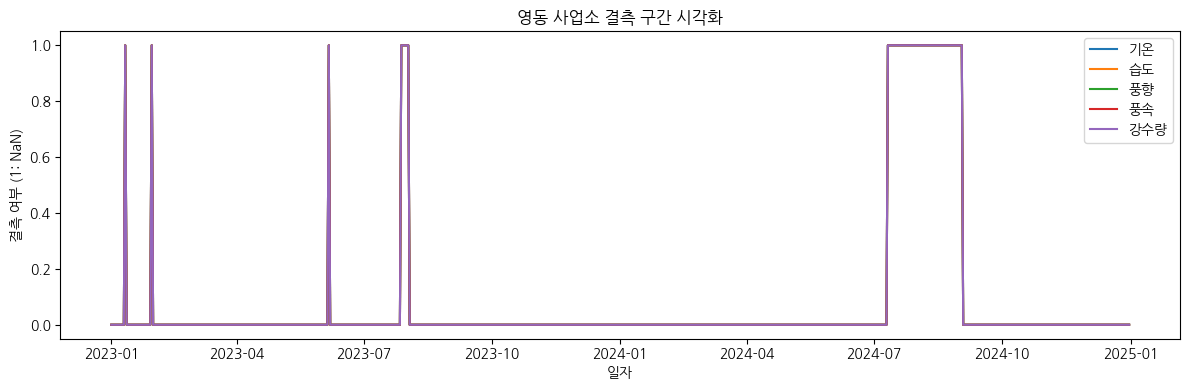

In [ ]:

plt.figure(figsize=(12, 4))
for col in missing_cols:
    plt.plot(
        yeongdong_df['일자'],
        yeongdong_df[col].isna().astype(int),
        label=col
    )

plt.title('영동 사업소 결측 구간 시각화')
plt.ylabel('결측 여부 (1: NaN)')
plt.xlabel('일자')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 마스크
# 통계, 산업공학과
# 

### 분당 일별 강수량 데이터

In [34]:
df2=pd.read_csv('./분당일별강수량.csv')
df2.head()

,date,일강수량
0,2023-01-01,0.0
1,2023-01-02,0.0
2,2023-01-03,0.0
3,2023-01-04,0.0
4,2023-01-05,0.0


In [35]:
df2['사업소']='분당'

In [25]:
df2.head()

,date,일강수량,사업소
0,2023-01-01,0.0,분당
1,2023-01-02,0.0,분당
2,2023-01-03,0.0,분당
3,2023-01-04,0.0,분당
4,2023-01-05,0.0,분당


In [36]:
df2.rename(columns={'date':'일자','일강수량':'강수량'},inplace=True)

In [37]:
df2.head(10)

,일자,강수량,사업소
0,2023-01-01,0.0,분당
1,2023-01-02,0.0,분당
2,2023-01-03,0.0,분당
3,2023-01-04,0.0,분당
4,2023-01-05,0.0,분당
5,2023-01-06,36.2,분당
6,2023-01-07,0.0,분당
7,2023-01-08,0.3,분당
8,2023-01-09,0.0,분당
9,2023-01-10,0.0,분당


### 분당 강수량 추가

In [36]:
df2.head(10)

,일자,강수량,사업소
0,2023-01-01,0.0,분당
1,2023-01-02,0.0,분당
2,2023-01-03,0.0,분당
3,2023-01-04,0.0,분당
4,2023-01-05,0.0,분당
5,2023-01-06,36.2,분당
6,2023-01-07,0.0,분당
7,2023-01-08,0.3,분당
8,2023-01-09,0.0,분당
9,2023-01-10,0.0,분당


In [38]:
# 분당만 새로운 값으로 업데이트
filled_df.loc[filled_df['사업소'] == '분당', '강수량'] = df2['강수량'].values
filled_df.head(10)

,사업소,일자,기온,습도,풍향,풍속,강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,0.0
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,0.0
2,분당,2023-01-03,-7.28,56.97,325.07,1.49,0.0
3,분당,2023-01-04,-5.12,68.63,324.83,1.50,0.0
4,분당,2023-01-05,-4.20,72.47,324.25,1.42,0.0
5,분당,2023-01-06,0.38,99.96,326.00,1.59,36.2
6,분당,2023-01-07,-2.72,94.20,325.73,1.57,0.0
7,분당,2023-01-08,1.86,68.79,324.00,1.36,0.3
8,분당,2023-01-09,-1.76,63.46,324.90,1.45,0.0
9,분당,2023-01-10,-1.66,81.52,339.86,3.25,0.0


In [ ]:
# df2.to_csv('./분당일별강수량_사업소컬럼추가.csv',index=False)

## 결측치 처리

In [ ]:
rainfall_null_df=df[df['강수량'].isna()]
rainfall_null_df.head()

In [41]:
filled_df[filled_df['강수량'].isna()]

,사업소,일자,기온,습도,풍향,풍속,강수량
778,삼천포,2023-02-17,NaN,NaN,NaN,NaN,NaN
779,삼천포,2023-02-18,NaN,NaN,NaN,NaN,NaN
780,삼천포,2023-02-19,NaN,NaN,NaN,NaN,NaN
781,삼천포,2023-02-20,NaN,NaN,NaN,NaN,NaN
782,삼천포,2023-02-21,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
3645,영흥,2024-12-22,NaN,NaN,NaN,NaN,NaN
3646,영흥,2024-12-23,NaN,NaN,NaN,NaN,NaN
3647,영흥,2024-12-24,NaN,NaN,NaN,NaN,NaN
3648,영흥,2024-12-25,NaN,NaN,NaN,NaN,NaN


In [39]:
filled_df.isna().sum()

사업소      0
일자       0
기온     315
습도     315
풍향     315
풍속     318
강수량    326
dtype: int64

In [40]:
filled_df[filled_df['기온'].isna()].groupby('사업소').count()

,일자,기온,습도,풍향,풍속,강수량
사업소,,,,,,
분당,3,0,0,0,0,3
삼천포,128,0,0,0,0,0
영동,63,0,0,0,0,0
영흥,121,0,0,0,0,0


In [51]:
filled_df[filled_df['습도'].isna()].groupby('사업소').count()

,일자,기온,습도,풍향,풍속,강수량
사업소,,,,,,
분당,3,0,0,0,0,3
삼천포,128,0,0,0,0,0
영동,63,0,0,0,0,0
영흥,121,0,0,0,0,0


In [52]:
filled_df[filled_df['풍속'].isna()].groupby('사업소').count()

,일자,기온,습도,풍향,풍속,강수량
사업소,,,,,,
분당,3,0,0,0,0,3
삼천포,128,0,0,0,0,0
여수,3,3,3,3,0,3
영동,63,0,0,0,0,0
영흥,121,0,0,0,0,0


In [49]:
filled_df[filled_df['강수량'].isna()].groupby('사업소').count()

,일자,기온,습도,풍향,풍속,강수량
사업소,,,,,,
삼천포,128,0,0,0,0,0
여수,2,2,2,2,2,0
영동,63,0,0,0,0,0
영흥,133,12,12,12,12,0


### 시계열 보간

In [ ]:
# 결측치 보간 대상 컬럼
target_cols = ["기온", "습도", "풍향", "풍속", "강수량"]

# 사업소별로 정렬하고 선형 보간 수행
# 사업소별로 정렬된 상태에서 그룹 단위로 보간을 수행하고, index 정렬을 맞춤
df_sorted = filled_df.sort_values(by=["사업소", "일자"]).reset_index(drop=True)


# 각 그룹에 대해 보간 결과를 수집하여 DataFrame으로 재조합
interpolated_list = []

for name, group in df_sorted.groupby("사업소"):
    group[target_cols] = group[target_cols].interpolate(method="linear", limit_direction="both", limit=5) # 연속 5일 이내 결측치만 보간
    interpolated_list.append(group)

# 보간 완료된 그룹을 다시 합침
df_interpolated_final = pd.concat(interpolated_list).sort_values(by=["사업소", "일자"]).reset_index(drop=True)


In [42]:
df_interpolated_final.isna().sum()

사업소      0
일자       0
기온     173
습도     173
풍향     173
풍속     173
강수량    173
dtype: int64

In [46]:
filled_df[filled_df['기온'].isna()].groupby('사업소').count()

,일자,기온,습도,풍향,풍속,강수량
사업소,,,,,,
분당,3,0,0,0,0,3
삼천포,128,0,0,0,0,0
영동,63,0,0,0,0,0
영흥,121,0,0,0,0,0


In [45]:
df_interpolated_final[df_interpolated_final['기온'].isna()].groupby('사업소').count()

,일자,기온,습도,풍향,풍속,강수량
사업소,,,,,,
삼천포,83,0,0,0,0,0
영동,44,0,0,0,0,0
영흥,46,0,0,0,0,0


In [47]:
df_interpolated_final[df_interpolated_final['강수량'].isna()].groupby('사업소').count()

,일자,기온,습도,풍향,풍속,강수량
사업소,,,,,,
삼천포,83,0,0,0,0,0
영동,44,0,0,0,0,0
영흥,46,0,0,0,0,0


In [43]:
df_interpolated_final['사업소'].value_counts()

분당     731
삼천포    731
여수     731
영흥     731
영동     731
Name: 사업소, dtype: int64

In [50]:
df_interpolated_final.to_csv('기상정보_결측치처리_5일이하.csv', index=False, encoding='cp949')

### 보간 데이터 시각화

In [ ]:
def plot_interpolation_comparison(original_df, interpolated_df, site, column):
    # 사업소 필터링
    mask = original_df["사업소"] == site
    site_original = original_df[mask]
    site_interpolated = interpolated_df[mask]

    # 연도 추출
    years = site_original["일자"].dt.year.unique()

    for year in years:
        # 연도 필터링
        year_mask = site_original["일자"].dt.year == year
        dates = site_original.loc[year_mask, "일자"]
        original_vals = site_original.loc[year_mask, column]
        interpolated_vals = site_interpolated.loc[year_mask, column]
        nan_mask = original_vals.isna()

        # 시각화
        plt.figure(figsize=(10, 4))
        plt.plot(dates, original_vals, 'o-', label='원본', color='gray')
        plt.plot(dates, interpolated_vals,  label='보간 후', color='blue')
        plt.scatter(dates[nan_mask], interpolated_vals[nan_mask], color='red', label='보간된 지점', zorder=5)

        plt.title(f"{site} 사업소 - {year}년 {column} 보간 비교")
        plt.xlabel("일자")
        plt.ylabel(column)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

#### 강수량

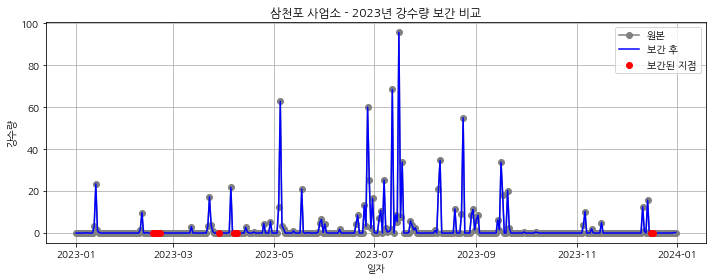

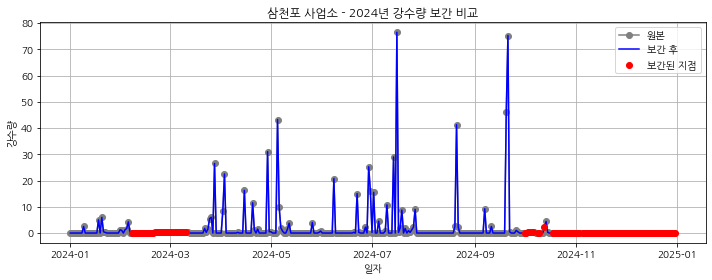

In [71]:
plot_interpolation_comparison(filled_df, df_interpolated_final, "삼천포", "강수량")

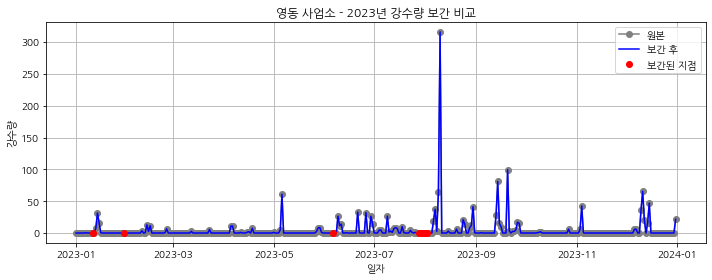

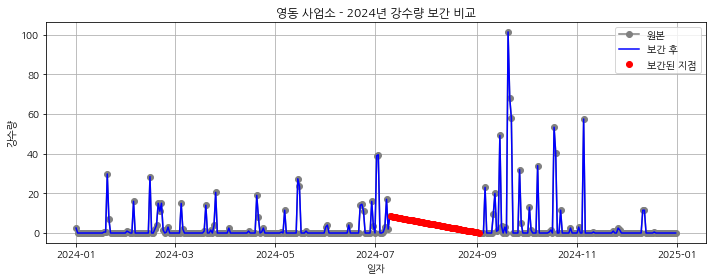

In [72]:
plot_interpolation_comparison(filled_df, df_interpolated_final, "영동", "강수량")

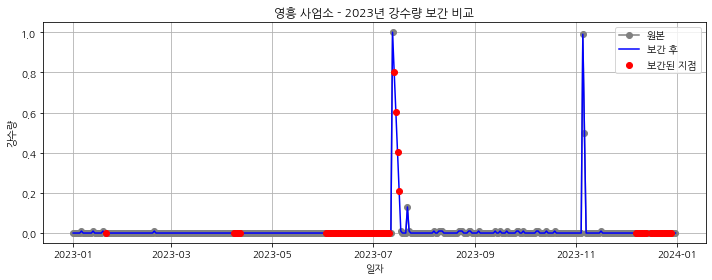

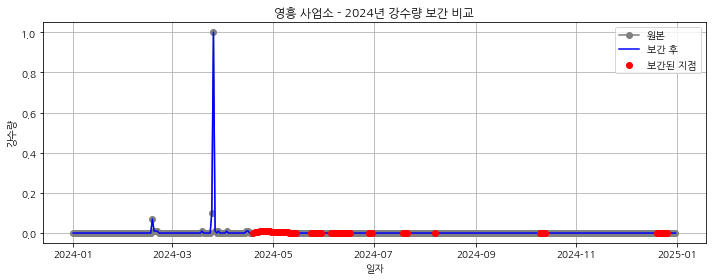

In [73]:
plot_interpolation_comparison(filled_df, df_interpolated_final, "영흥", "강수량")

#### 기온

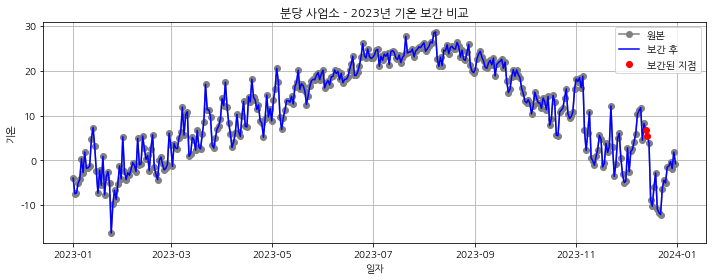

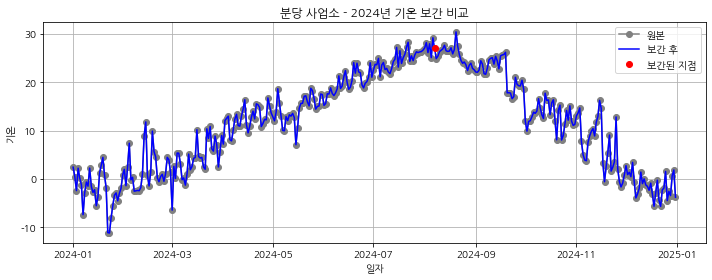

In [74]:
plot_interpolation_comparison(filled_df, df_interpolated_final, "분당", "기온")

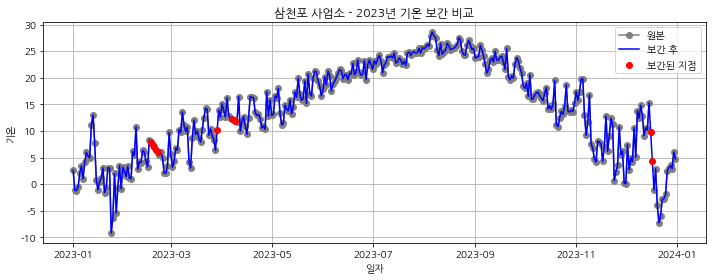

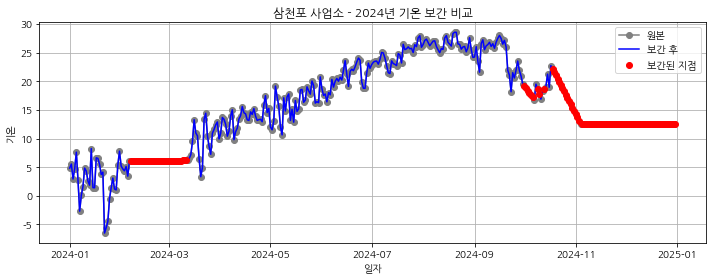

In [75]:
plot_interpolation_comparison(filled_df, df_interpolated_final, "삼천포", "기온")

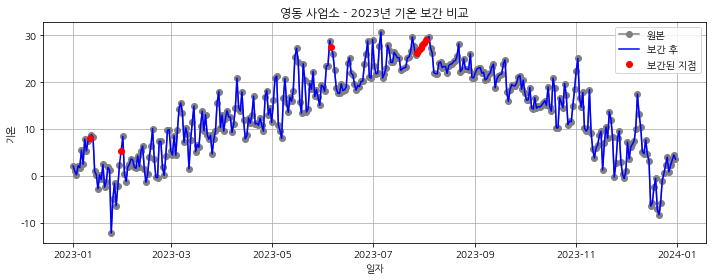

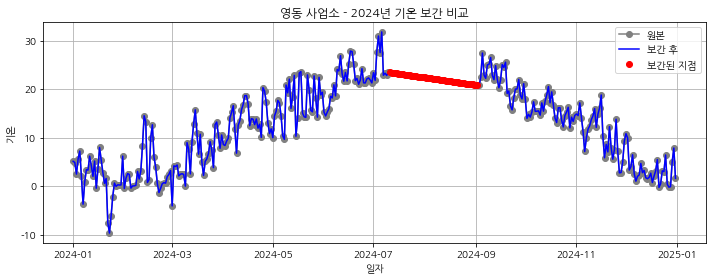

In [76]:
plot_interpolation_comparison(filled_df, df_interpolated_final, "영동", "기온")

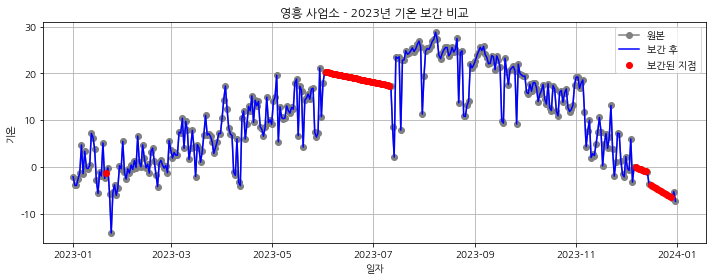

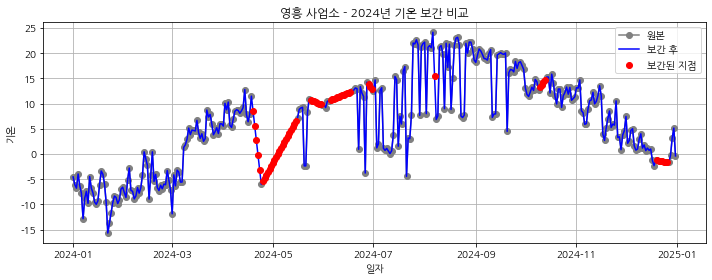

In [77]:
plot_interpolation_comparison(filled_df, df_interpolated_final, "영흥", "기온")

### 2022년 데이터 참조

In [20]:
df3 = pd.read_csv('한국남동발전_기상정보(일평균)_2022.csv', encoding='cp949')
df3[' 일자'] = pd.to_datetime(df3[' 일자'], format='%Y%m%d')
df3.head()

,사업소,호기,일자,온도,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,-,2022-12-31,-2.03,80.13,325.44,1.54,,,,,,,,
1,삼천포,-,2022-12-31,-0.59,57.31,64.28,2.05,0,,5.39,,,,,
2,영동,-,2022-12-31,3.49,45.44,277.23,4.77,0,1022.25,,0,0,,,
3,영흥,내2리,2022-12-31,3.91,52.86,238.99,2.74,,,,,,,,
4,영흥,내6리,2022-12-31,4.39,53.62,257.02,3.02,,,,,,,,


In [21]:
df3.columns = df3.columns.str.strip()

In [19]:
df3.columns

Index(['사업소', '호기', '일자', '온도', '습도', '풍향', '풍속', '강수량', '기압', '대기안정도', '증발량',
       '일조시간', '전일강수량', '60분강수량', '금일강수량'],
      dtype='object')

In [22]:
df3 = df3.drop(columns={'기압', '대기안정도', '증발량', '일조시간', '전일강수량', '60분강수량', '금일강수량'}, axis=1)
df3.head()

,사업소,호기,일자,온도,습도,풍향,풍속,강수량
0,분당,-,2022-12-31,-2.03,80.13,325.44,1.54,
1,삼천포,-,2022-12-31,-0.59,57.31,64.28,2.05,0
2,영동,-,2022-12-31,3.49,45.44,277.23,4.77,0
3,영흥,내2리,2022-12-31,3.91,52.86,238.99,2.74,
4,영흥,내6리,2022-12-31,4.39,53.62,257.02,3.02,


In [10]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2672 entries, 0 to 2671
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   사업소     2672 non-null   object 
 1    호기     2672 non-null   object 
 2    일자     2672 non-null   int64  
 3    온도     2672 non-null   float64
 4    습도     2672 non-null   float64
 5    풍향     2672 non-null   float64
 6    풍속     2672 non-null   float64
 7    강수량    2672 non-null   object 
dtypes: float64(4), int64(1), object(3)
memory usage: 167.1+ KB


In [48]:
df3.groupby(['사업소', '호기']).count()

일자   온도   습도   풍향   풍속  강수량
사업소 호기                                
분당   -    328  328  328  328  328  328
삼천포  -    335  335  335  335  335  335
영동   -    335  335  335  335  335  335
영흥   내2리  335  335  335  335  335  335
     내6리  335  335  335  335  335  335
     선재도  334  334  334  334  334  334
     외1리  335  335  335  335  335  335
     외3리  335  335  335  335  335  335

In [ ]:
df['일자'] = pd.to_datetime(df['일자'])

# 사업소별로 누락된 날짜를 포함한 데이터 생성
filled_df = (
    df.set_index('일자')
      .groupby('사업소', group_keys=False)  # group_keys=False로 중복 삽입 방지
      .apply(lambda x: x.asfreq('D'))
      .reset_index()
)

filled_df.head(10)


In [49]:
missing_by_location = (
    df3
    .groupby('사업소')
    .apply(lambda x: x.isna().sum())
    .drop(columns=['사업소', '일자'])  # 필요시 제외
)

print(missing_by_location)


     호기  온도  습도  풍향  풍속  강수량
사업소                         
분당    0   0   0   0   0    0
삼천포   0   0   0   0   0    0
영동    0   0   0   0   0    0
영흥    0   0   0   0   0    0


In [ ]:
df3.sort_index

### LSTM 모델링

### 사업소-일자별 시계열 추세

In [21]:
df.head()

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,NaN,NaN,-3.96,46.07,325.03,1.51,NaN,NaN
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,NaN,NaN,-7.45,63.39,324.52,1.44,NaN,NaN
2,분당,2023-01-03,-7.28,56.97,325.07,1.49,NaN,NaN,-7.28,56.97,325.07,1.49,NaN,NaN
3,분당,2023-01-04,-5.12,68.63,324.83,1.50,NaN,NaN,-5.12,68.63,324.83,1.50,NaN,NaN
4,분당,2023-01-05,-4.20,72.47,324.25,1.42,NaN,NaN,-4.20,72.47,324.25,1.42,NaN,NaN


In [24]:
df['사업소'].value_counts()

사업소
여수     731
분당     728
영동     669
영흥     610
삼천포    603
Name: count, dtype: int64

#### 기온

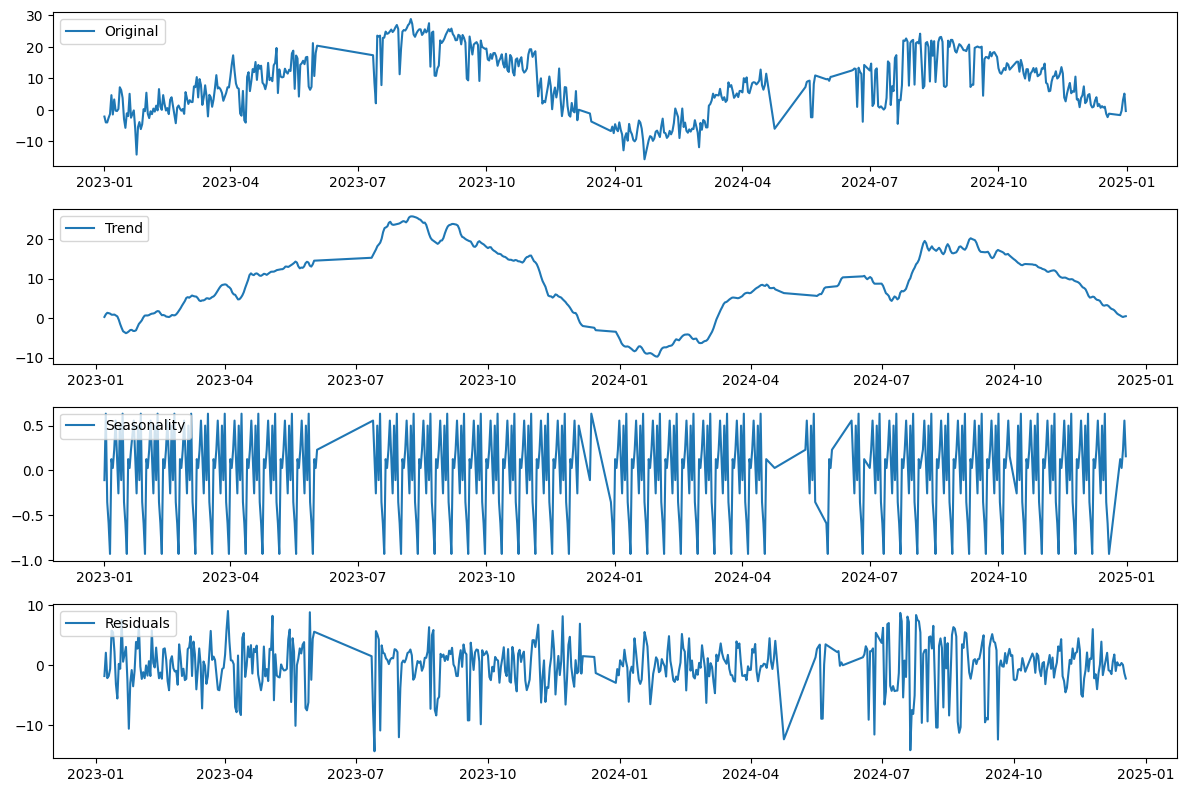

In [23]:

stations = df["사업소"].unique()

# 한 사업소의 데이터만 시계열 분해 예시로 확인 (예: 첫 번째 사업소)
sample_station = stations[4]
df_sample = df[df["사업소"] == sample_station].copy()

# 일자 기준 정렬 및 인덱스 설정
df_sample.sort_values("일자", inplace=True)
df_sample.set_index("일자", inplace=True)

# 시계열 분해를 위한 컬럼 선택: 예시로 '기온' 사용
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 분해 (기온 기준)
decomposition = seasonal_decompose(df_sample["기온"], model='additive', period=12)

# 분해된 시계열 요소 반환
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# 세 요소를 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df_sample["기온"], label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


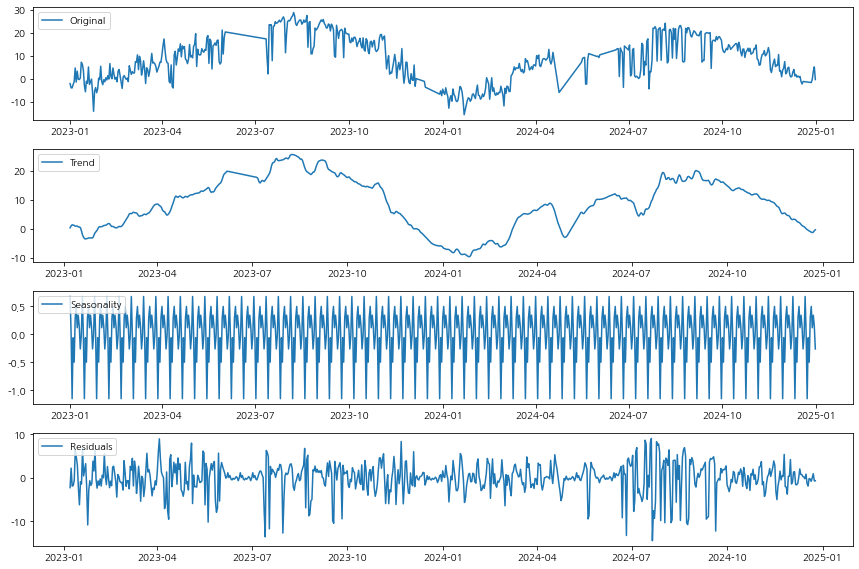

In [59]:

stations = df_interpolated_final["사업소"].unique()

# 한 사업소의 데이터만 시계열 분해 예시로 확인 (예: 첫 번째 사업소)
sample_station = stations[4]
df_sample = df_interpolated_final[df_interpolated_final["사업소"] == sample_station].copy()

# 일자 기준 정렬 및 인덱스 설정
df_sample.sort_values("일자", inplace=True)
df_sample.set_index("일자", inplace=True)

# 시계열 분해를 위한 컬럼 선택: 예시로 '기온' 사용
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 분해 (기온 기준)
decomposition = seasonal_decompose(df_sample["기온"], model='additive', period=12)

# 분해된 시계열 요소 반환
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# 세 요소를 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df_sample["기온"], label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


#### 강수량

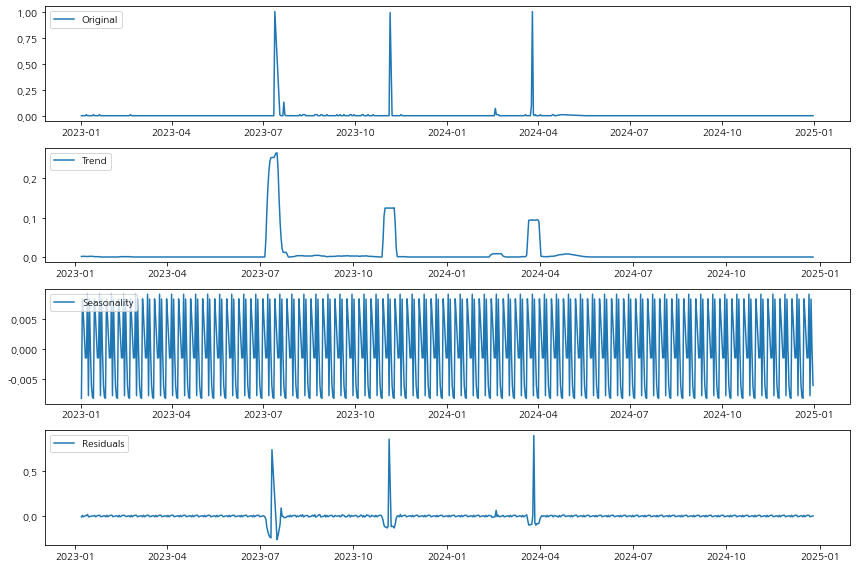

In [60]:
stations = df_interpolated_final["사업소"].unique()

# 한 사업소의 데이터만 시계열 분해 예시로 확인 (예: 첫 번째 사업소)
sample_station = stations[4]
df_sample = df_interpolated_final[df_interpolated_final["사업소"] == sample_station].copy()

# 일자 기준 정렬 및 인덱스 설정
df_sample.sort_values("일자", inplace=True)
df_sample.set_index("일자", inplace=True)

# 시계열 분해를 위한 컬럼 선택: 예시로 '강수량' 사용
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 분해 (기온 기준)
decomposition = seasonal_decompose(df_sample["강수량"], model='additive', period=12)

# 분해된 시계열 요소 반환
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# 세 요소를 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df_sample["강수량"], label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [57]:
# 결측치 있는 데이터 필터링 출력

rainfall_null_df=df[df['강수량'].isna()]
rainfall_null_df.head()

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,NaN,NaN,-3.96,46.07,325.03,1.51,NaN,NaN
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,NaN,NaN,-7.45,63.39,324.52,1.44,NaN,NaN
2,분당,2023-01-03,-7.28,56.97,325.07,1.49,NaN,NaN,-7.28,56.97,325.07,1.49,NaN,NaN
3,분당,2023-01-04,-5.12,68.63,324.83,1.50,NaN,NaN,-5.12,68.63,324.83,1.50,NaN,NaN
4,분당,2023-01-05,-4.20,72.47,324.25,1.42,NaN,NaN,-4.20,72.47,324.25,1.42,NaN,NaN


In [58]:
rainfall_null_df.describe()

,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
count,743,742.000000,742.000000,742.000000,742.000000,0.0,2.000000,740.000000,740.000000,740.000000,740.000000,0.0,0.0
mean,2023-12-28 23:38:40.861372928,11.477761,79.637328,328.922680,2.284141,NaN,1001.952083,11.443782,79.598172,329.491390,2.280314,NaN,NaN
min,2023-01-01 00:00:00,-16.220000,25.240000,42.200000,0.010000,NaN,1000.958333,-16.220000,25.240000,158.447500,0.010000,NaN,NaN
25%,2023-06-28 12:00:00,2.457500,67.012500,331.010000,2.240000,NaN,1001.455208,2.445000,67.002500,331.010000,2.240000,NaN,NaN
50%,2023-12-28 00:00:00,12.460000,83.240000,332.000000,2.335000,NaN,1001.952083,12.420000,83.040000,332.005000,2.330000,NaN,NaN
75%,2024-06-30 12:00:00,20.410000,96.025000,334.010000,2.580000,NaN,1002.448958,20.312500,96.042500,334.010000,2.580000,NaN,NaN
max,2024-12-31 00:00:00,30.440000,100.000000,346.000000,4.800000,NaN,1002.945833,30.440000,100.000000,346.000000,3.920000,NaN,NaN
std,NaN,10.161534,18.037920,21.531323,0.548010,NaN,1.405375,10.154120,18.046538,18.136749,0.540752,NaN,NaN


In [59]:
rainfall_null_df.describe(include='O')

,사업소
count,743
unique,4
top,분당
freq,728


In [60]:
rainfall_null_df['사업소'].value_counts()

사업소
분당    728
영흥     12
여수      2
영동      1
Name: count, dtype: int64

In [ ]:
# 기온, 습도, 강수량
# 731

# 영동     669 -> 강원 강릉 강동면 염전길
# 영흥     610 -> 인ㄴ천 옹진군 영흥면 외리
# 삼천포    603 -> 경남 고성 하이면 (130 )
# 

In [61]:
df['사업소'].value_counts()

사업소
여수     731
분당     728
영동     669
영흥     610
삼천포    603
Name: count, dtype: int64

In [62]:
# 날짜 형식을 통일 (datetime으로)
df['일자'] = pd.to_datetime(df['일자'], errors='coerce')
df2['일자'] = pd.to_datetime(df2['일자'], errors='coerce')

# 병합 재시도
df_merged = df.merge(df2, on='일자', how='left', suffixes=('', '_분당'))

# 분당 사업소 결측치 채움
df_merged.loc[
    (df_merged['사업소'] == '분당') & (df_merged['강수량'].isna()),
    '강수량'
] = df_merged['강수량_분당']

# 보조 컬럼 제거
df_merged.drop(columns=['강수량_분당', '사업소_분당'], errors='ignore', inplace=True)


In [63]:
df2.shape

(731, 3)

In [64]:
df_merged.head()

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,0.0,NaN,-3.96,46.07,325.03,1.51,NaN,NaN
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,0.0,NaN,-7.45,63.39,324.52,1.44,NaN,NaN
2,분당,2023-01-03,-7.28,56.97,325.07,1.49,0.0,NaN,-7.28,56.97,325.07,1.49,NaN,NaN
3,분당,2023-01-04,-5.12,68.63,324.83,1.50,0.0,NaN,-5.12,68.63,324.83,1.50,NaN,NaN
4,분당,2023-01-05,-4.20,72.47,324.25,1.42,0.0,NaN,-4.20,72.47,324.25,1.42,NaN,NaN


In [65]:
df_merged.isna().sum()

사업소          0
일자           0
기온           1
습도           1
풍향           1
풍속           4
강수량         15
기압        1942
대기안정도      732
증발량        732
일조시간       732
전일강수량      732
60분강수량    1472
금일강수량     1944
dtype: int64

In [66]:
# 기온 결측 컬럼 
df_merged[df_merged['기온'].isnull()]

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
2072,영동,2023-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
# 습도 결측 컬럼
df_merged[df_merged['습도'].isnull()]


,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
2072,영동,2023-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
# 풍속 결측 컬럼
df_merged[df_merged['풍속'].isnull()]

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
1400,여수,2023-03-11,14.0,72.000000,248.0,NaN,0.0,1013.775000,NaN,NaN,NaN,NaN,NaN,0.0
1466,여수,2023-05-16,21.9,69.791667,300.0,NaN,0.0,1003.295833,NaN,NaN,NaN,NaN,NaN,0.0
1812,여수,2024-04-26,17.1,80.333333,133.0,NaN,0.0,1001.291667,NaN,NaN,NaN,NaN,NaN,0.0
2072,영동,2023-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
# 강수량 결측 컬럼

df_merged[df_merged['강수량'].isnull()]

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
1507,여수,2023-06-26,24.700000,94.041667,194.800000,4.800000,NaN,1000.958333,NaN,NaN,NaN,NaN,NaN,NaN
1587,여수,2023-09-14,23.400000,94.208333,42.200000,2.600000,NaN,1002.945833,NaN,NaN,NaN,NaN,NaN,NaN
2072,영동,2023-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2827,영흥,2023-04-08,-1.162500,63.987500,233.757500,1.355000,NaN,NaN,-1.162500,63.987500,233.757500,1.355000,NaN,NaN
2828,영흥,2023-04-09,-1.842500,68.070000,162.140000,0.487500,NaN,NaN,-1.842500,68.070000,162.140000,0.487500,NaN,NaN
2829,영흥,2023-04-10,6.012500,51.302500,158.447500,1.740000,NaN,NaN,6.012500,51.302500,158.447500,1.740000,NaN,NaN
2830,영흥,2023-04-11,-3.332500,52.372500,213.985000,1.042500,NaN,NaN,-3.332500,52.372500,213.985000,1.042500,NaN,NaN
2831,영흥,2023-04-12,-4.040000,62.465000,206.085000,0.787500,NaN,NaN,-4.040000,62.465000,206.085000,0.787500,NaN,NaN
2885,영흥,2023-07-14,2.090000,66.336667,208.270000,2.240000,NaN,NaN,2.090000,66.336667,208.270000,2.240000,NaN,NaN
2886,영흥,2023-07-15,23.550000,92.120000,201.536667,1.506667,NaN,NaN,23.550000,92.120000,201.536667,1.506667,NaN,NaN


In [23]:
df_merged.shape

NameError: name 'df_merged' is not defined

In [71]:
df_merged['사업소'].value_counts()

사업소
여수     731
분당     728
영동     669
영흥     610
삼천포    603
Name: count, dtype: int64

In [75]:
df_merged.to_csv('./기상정보_결측치처리전.csv',index=False)

### 결측치 처리

In [76]:
# 기온이 결측값으로 포함한 행을 처리하면 
df_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3341 entries, 0 to 3340
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   사업소     3341 non-null   object        
 1   일자      3341 non-null   datetime64[ns]
 2   기온      3340 non-null   float64       
 3   습도      3340 non-null   float64       
 4   풍향      3340 non-null   float64       
 5   풍속      3337 non-null   float64       
 6   강수량     3326 non-null   float64       
 7   기압      1399 non-null   float64       
 8   대기안정도   2609 non-null   float64       
 9   증발량     2609 non-null   float64       
 10  일조시간    2609 non-null   float64       
 11  전일강수량   2609 non-null   float64       
 12  60분강수량  1869 non-null   float64       
 13  금일강수량   1397 non-null   float64       
dtypes: datetime64[ns](1), float64(12), object(1)
memory usage: 365.5+ KB


In [78]:

# 결측치 보간 대상 컬럼
target_cols = ["기온", "습도", "풍향", "풍속", "강수량"]

# 사업소별로 정렬하고 선형 보간 수행
# 사업소별로 정렬된 상태에서 그룹 단위로 보간을 수행하고, index 정렬을 맞춤
df_sorted = df_merged.sort_values(by=["사업소", "일자"]).reset_index(drop=True)

# 각 그룹에 대해 보간 결과를 수집하여 DataFrame으로 재조합
interpolated_list = []

for name, group in df_sorted.groupby("사업소"):
    group[target_cols] = group[target_cols].interpolate(method="linear", limit_direction="both")
    interpolated_list.append(group)

# 보간 완료된 그룹을 다시 합침
df_interpolated_final = pd.concat(interpolated_list).sort_values(by=["사업소", "일자"]).reset_index(drop=True)


In [79]:
df_interpolated_final.head()

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,2023-01-01,-3.96,46.07,325.03,1.51,0.0,NaN,-3.96,46.07,325.03,1.51,NaN,NaN
1,분당,2023-01-02,-7.45,63.39,324.52,1.44,0.0,NaN,-7.45,63.39,324.52,1.44,NaN,NaN
2,분당,2023-01-03,-7.28,56.97,325.07,1.49,0.0,NaN,-7.28,56.97,325.07,1.49,NaN,NaN
3,분당,2023-01-04,-5.12,68.63,324.83,1.50,0.0,NaN,-5.12,68.63,324.83,1.50,NaN,NaN
4,분당,2023-01-05,-4.20,72.47,324.25,1.42,0.0,NaN,-4.20,72.47,324.25,1.42,NaN,NaN


In [81]:
df_interpolated_final.isna().sum()

사업소          0
일자           0
기온           0
습도           0
풍향           0
풍속           0
강수량          0
기압        1942
대기안정도      732
증발량        732
일조시간       732
전일강수량      732
60분강수량    1472
금일강수량     1944
dtype: int64

In [84]:
df=df_interpolated_final.copy()

### 사업소별 강수량 추세

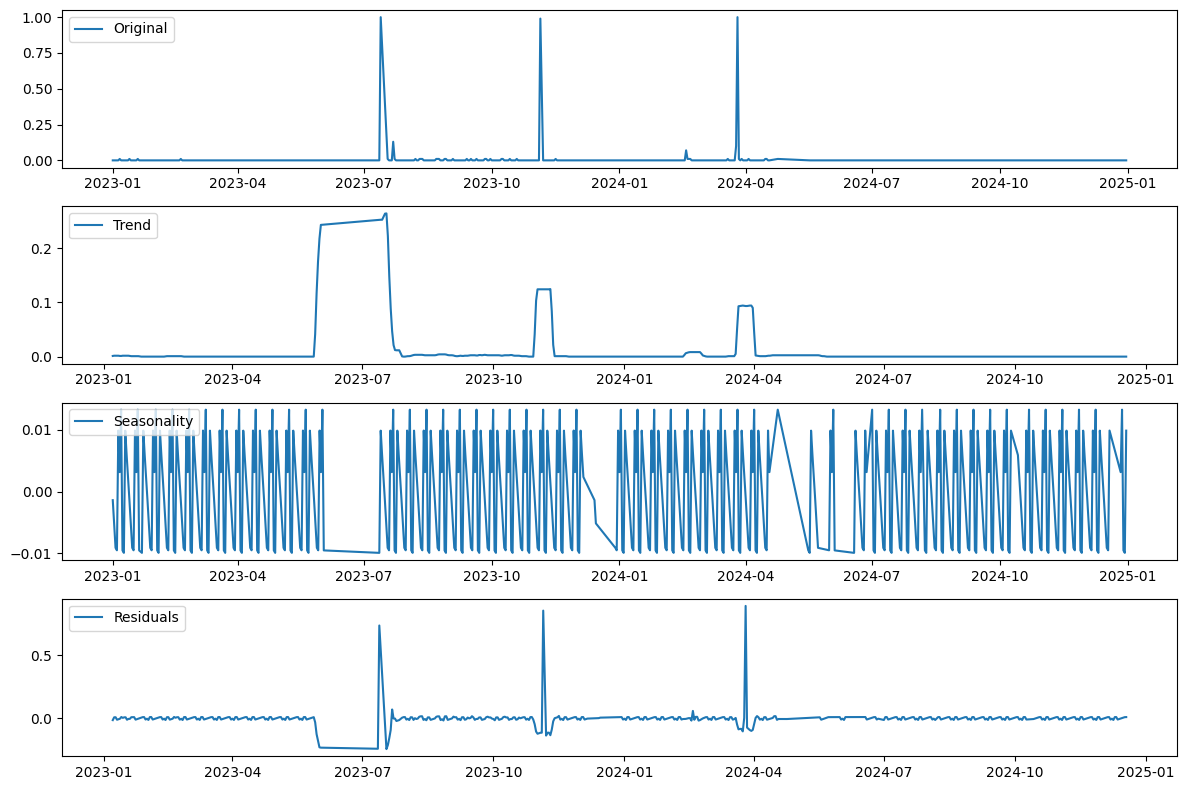

In [89]:

stations = df["사업소"].unique()

# 한 사업소의 데이터만 시계열 분해 예시로 확인 (예: 첫 번째 사업소)
sample_station = stations[4]
df_sample = df[df["사업소"] == sample_station].copy()

# 일자 기준 정렬 및 인덱스 설정
df_sample.sort_values("일자", inplace=True)
df_sample.set_index("일자", inplace=True)

# 시계열 분해를 위한 컬럼 선택: 예시로 '강수량' 사용
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 분해 (강수량 기준)
decomposition = seasonal_decompose(df_sample["강수량"], model='additive', period=12)

# 분해된 시계열 요소 반환
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# 세 요소를 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df_sample["강수량"], label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [91]:
df.isna().sum()

사업소          0
일자           0
기온           0
습도           0
풍향           0
풍속           0
강수량          0
기압        1942
대기안정도      732
증발량        732
일조시간       732
전일강수량      732
60분강수량    1472
금일강수량     1944
dtype: int64

In [92]:
df_merged.to_csv('./기상정보_전처리후.csv',index=False)